# Imports & config

In [1]:
import os
from pathlib import Path
import mne
import numpy as np
import matplotlib.pyplot as plt
from mne.time_frequency import psd_array_welch
import pandas as pd
from typing import Optional, List, Tuple, Dict

# plotting defaults
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

OUT_DIR = Path('./figures')
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('MNE version:', mne.__version__)

MNE version: 1.10.1


In [2]:
# Utility: load EDF (single file) - returns Raw
def load_edf(path: str, preload=True) -> mne.io.Raw:
    raw = mne.io.read_raw_edf(path, preload=preload, verbose='ERROR')
    return raw

In [3]:
# Utility: Print summary info
def print_eeg_info(raw: mne.io.Raw):
    print('\n' + '='*60)
    subj = raw.info.get('subject_info', {}).get('his_id', 'unknown')
    print(f"EEG DATA INFO: subject={subj}")
    print('='*60)
    print(f"Duration: {raw.times[-1]/60:.2f} min | sfreq: {raw.info['sfreq']} Hz | n_channels: {len(raw.ch_names)}")
    print('\nChannels:')
    print(raw.ch_names)

In [4]:
# Channel typing: ensure LOC1/LOC2 -> eog and sensible eeg detection
def set_custom_channel_types(raw: mne.io.Raw, loc_names: List[str] = ['LOC1', 'LOC2']):
    ch_types = {}
    for ch in raw.ch_names:
        # if channel appears like LOC* or ROC* mark as eog
        if any(ch.upper().startswith(x.upper()) for x in loc_names) or ch.upper().startswith('ROC'):
            ch_types[ch] = 'eog'
        # some common prefixes
        elif ch.upper().startswith('EMG'):
            ch_types[ch] = 'emg'
        elif ch.upper().startswith('EKG') or ch.upper().startswith('ECG'):
            ch_types[ch] = 'ecg'
        # fallback: try to detect standard 10-20
        else:
            ch_types[ch] = 'eeg'  # conservative: treat as EEG unless known otherwise
    raw.set_channel_types(ch_types)
    print(f"Set channel types. Marked {', '.join(ch for ch,t in ch_types.items() if t=='eog')} as EOG")

In [5]:
# Montage & reference helpers
def try_set_montage(raw: mne.io.Raw, montage_name: str = 'standard_1020'):
    try:
        montage = mne.channels.make_standard_montage(montage_name)
        raw.set_montage(montage, on_missing='warn')
        print('Montage set:', montage_name)
    except Exception as e:
        print('Could not set montage:', e)

In [6]:
def set_reference(raw: mne.io.Raw, ref_channels: Optional[List[str]] = None):
    if ref_channels is None:
        raw.set_eeg_reference('average')
        print('Set average reference')
    else:
        raw.set_eeg_reference(ref_channels)
        print('Set reference to:', ref_channels)

In [7]:
def apply_filters(raw: mne.io.Raw, l_freq: Optional[float], h_freq: Optional[float], notch_freqs: Optional[List[float]] = None):
    raw_filtered = raw.copy()
    raw_filtered.load_data()
    if l_freq is not None or h_freq is not None:
        raw_filtered.filter(l_freq=l_freq, h_freq=h_freq, fir_design='firwin')
        print(f'Applied bandpass: {l_freq} - {h_freq} Hz')
    if notch_freqs:
        raw_filtered.notch_filter(freqs=notch_freqs, fir_design='firwin')
        print('Applied notch at:', notch_freqs)
    return raw_filtered

In [8]:
# PSD computation using psd_array_welch for arrays (fast) but also wrapper for Raw
def compute_psd(raw: mne.io.Raw, fmin=0.5, fmax=40.0, n_fft=2048, n_overlap=None, n_per_seg=None):
    picks = mne.pick_types(raw.info, eeg=True, eog=False, exclude='bads')
    if len(picks) == 0:
        raise RuntimeError('No EEG channels found for PSD')
    data = raw.get_data(picks=picks)
    sfreq = raw.info['sfreq']
    # defaults
    if n_overlap is None:
        n_overlap = n_fft // 2
    psds, freqs = psd_array_welch(data, sfreq=sfreq, fmin=fmin, fmax=fmax, n_fft=n_fft, n_overlap=n_overlap, n_per_seg=n_per_seg)
    # psds shape: (n_channels, n_freqs)
    ch_names = [raw.ch_names[p] for p in picks]
    return freqs, psds, ch_names

In [9]:
# Plot PSD for one channel or mean across channels
def plot_psd(freqs, psds, ch_names, picks: Optional[List[str]] = None, title: str = None, save_name: Optional[str] = None, fmin=0.5, fmax=40.0):
    if picks is None:
        # plot average across channels
        psd_to_plot = psds.mean(axis=0)
        label = 'Average EEG'
    else:
        # map picks names to indices
        indices = [ch_names.index(p) for p in picks if p in ch_names]
        if len(indices) == 0:
            raise RuntimeError('Picked channels not found in ch_names')
        psd_to_plot = psds[indices].mean(axis=0)
        label = ','.join([ch_names[i] for i in indices])
    plt.figure()
    plt.semilogy(freqs, psd_to_plot)
    plt.xlim(fmin, fmax)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('PSD (uV^2/Hz)')
    if title:
        plt.title(title)
    else:
        plt.title(f'PSD - {label}')
    if save_name:
        plt.savefig(OUT_DIR / save_name, dpi=200)
    plt.show()

In [10]:
# Band powers and topomap
def calculate_band_powers(psds: np.ndarray, freqs: np.ndarray, ch_names: List[str], bands: Optional[Dict[str, Tuple[float, float]]] = None) -> pd.DataFrame:
    if bands is None:
        bands = {
            'Delta': (0.5, 4),
            'Theta': (4, 8),
            'Alpha': (8, 13),
            'Beta': (13, 30),
            'Gamma': (30, 40)
        }
    band_powers = {}
    df_index = ch_names
    for band, (fmin, fmax) in bands.items():
        freq_idx = np.where((freqs >= fmin) & (freqs <= fmax))[0]
        # integrate PSD across band
        band_powers[band] = np.trapz(psds[:, freq_idx], x=freqs[freq_idx], axis=1)
    df = pd.DataFrame(band_powers, index=df_index)
    df.index.name = 'Channel'
    return df

In [11]:
def plot_band_topomaps(raw: mne.io.Raw, band_power_df: pd.DataFrame, save_name: Optional[str] = None, title: Optional[str] = None):
    # use only channels present in both raw and df
    chs = [ch for ch in band_power_df.index if ch in raw.ch_names]
    if len(chs) == 0:
        print('No matching channels for topomap')
        return
    raw_temp = raw.copy().pick(chs)
    # ensure montage present
    try:
        mne.channels.make_standard_montage('standard_1020')
        raw_temp.set_montage('standard_1020', on_missing='warn')
    except Exception:
        pass
    # plot
    fig = plt.figure(figsize=(14, 8))
    n = len(band_power_df.columns)
    for i, band in enumerate(band_power_df.columns):
        ax = fig.add_subplot(1, n, i+1)
        mne.viz.plot_topomap(band_power_df[band].values, raw_temp.info, axes=ax, show=False)
        ax.set_title(band)
    if title:
        fig.suptitle(title)
    if save_name:
        plt.savefig(OUT_DIR / save_name, dpi=200)
    plt.show()

In [12]:
# ICA artifact detection using EOG channels (LOC1/LOC2) if present
def run_ica_detect(raw: mne.io.Raw, eog_chs: List[str] = ['LOC1', 'LOC2'], n_components: Optional[int] = 0.95, random_state: int = 97):
    # prepare copy for ICA
    raw_ica = raw.copy()
    picks_eeg = mne.pick_types(raw_ica.info, eeg=True, eog=False, exclude='bads')

    ica = mne.preprocessing.ICA(n_components=n_components, random_state=random_state, max_iter='auto')
    print('Fitting ICA...')
    ica.fit(raw_ica, picks=picks_eeg)
    print('ICA fitted')

    # try to find EOG-related components using provided loc channels
    present_eog_chs = [ch for ch in eog_chs if ch in raw_ica.ch_names]
    eog_indices = []
    eog_scores = None
    if len(present_eog_chs) > 0:
        eog_indices, eog_scores = ica.find_bads_eog(raw_ica, ch_name=present_eog_chs)
        print('Found EOG ICs:', eog_indices)
    else:
        print('No LOC/ROC channels found in data for automatic EOG detection.')
    return ica, eog_indices, eog_scores

In [13]:
# Apply ICA exclusion and return cleaned raw
def apply_ica(raw: mne.io.Raw, ica: mne.preprocessing.ICA, exclude: List[int]):
    raw_clean = raw.copy()
    ica.exclude = exclude
    ica.apply(raw_clean)
    print('Applied ICA exclusions:', exclude)

In [14]:
# Full pipeline runner (example usage)
def pipeline_run(edf_path: str, out_prefix: str = 'subject'):
    # 0) load
    raw = load_edf(edf_path)
    print_eeg_info(raw)

    # 1) set types (map LOC1,LOC2)
    set_custom_channel_types(raw, loc_names=['LOC1', 'LOC2'])

    # quick raw plot
    raw.plot(n_channels=20, show=True, block=False)
    plt.savefig(OUT_DIR / f'{out_prefix}_raw.png', dpi=200)

    # 2) set montage & reference
    try_set_montage(raw)
    set_reference(raw, ref_channels=None)  # average

    # 3) initial PSD (before filtering)
    freqs_raw, psds_raw, ch_names = compute_psd(raw, fmin=0.5, fmax=40.0, n_fft=2048)
    plot_psd(freqs_raw, psds_raw, ch_names, picks=None, title='PSD - BEFORE filtering', save_name=f'{out_prefix}_psd_before.png')

    # 4) filtering
    raw_filt = apply_filters(raw, l_freq=0.5, h_freq=40.0, notch_freqs=[50.0, 100.0])
    freqs_filt, psds_filt, ch_names_filt = compute_psd(raw_filt, fmin=0.5, fmax=40.0, n_fft=2048)
    plot_psd(freqs_filt, psds_filt, ch_names_filt, picks=None, title='PSD - AFTER filtering', save_name=f'{out_prefix}_psd_after.png')

    # 5) band-power & topomap (after filtering)
    df_band = calculate_band_powers(psds_filt, freqs_filt, ch_names_filt)
    plot_band_topomaps(raw_filt, df_band, save_name=f'{out_prefix}_topomap_after_filter.png', title='Band powers - after filtering')

    # 6) ICA stage for artifact detection using LOC channels
    raw_ica_ready = raw_filt.copy()
    # highpass a bit for ICA stability
    raw_ica_ready.filter(l_freq=1.0, h_freq=None, fir_design='firwin')

    ica, eog_indices, eog_scores = run_ica_detect(raw_ica_ready, eog_chs=['LOC1', 'LOC2'])

    # plot components & scores
    ica.plot_components()  # interactive
    if eog_scores is not None:
        ica.plot_scores(eog_scores)

    # choose to exclude found eog comps
    exclude = eog_indices
    raw_clean = apply_ica(raw_filt, ica, exclude)

    # 7) PSD & topomap after ICA cleanup
    freqs_clean, psds_clean, ch_names_clean = compute_psd(raw_clean, fmin=0.5, fmax=40.0, n_fft=2048)
    plot_psd(freqs_clean, psds_clean, ch_names_clean, picks=None, title='PSD - AFTER ICA cleanup', save_name=f'{out_prefix}_psd_after_ica.png')
    df_band_clean = calculate_band_powers(psds_clean, freqs_clean, ch_names_clean)
    plot_band_topomaps(raw_clean, df_band_clean, save_name=f'{out_prefix}_topomap_after_ica.png', title='Band powers - after ICA')

    # save cleaned Raw if desired
    cleaned_fname = f'{out_prefix}_cleaned_raw.fif'
    raw_clean.save(cleaned_fname, overwrite=True)
    print('Saved cleaned raw to', cleaned_fname)

    return raw, raw_filt, raw_clean



EEG DATA INFO: subject=X
Duration: 9.47 min | sfreq: 256.0 Hz | n_channels: 46

Channels:
['Fp1', 'F7', 'T3', 'T5', 'O1', 'F3', 'C3', 'P3', 'A1', 'Fz', 'Cz', 'Fp2', 'F8', 'T4', 'T6', 'O2', 'F4', 'C4', 'P4', 'A2', 'Fpz', 'Pz', 'T1', 'T2', 'EKGL', 'EKGR', 'LOC1', 'LOC2', 'EMG1', 'EMG2', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'DC1', 'DC2', 'DC3', 'DC4', 'OSAT', 'PR']
Set channel types. Marked LOC1, LOC2 as EOG
Using matplotlib as 2D backend.


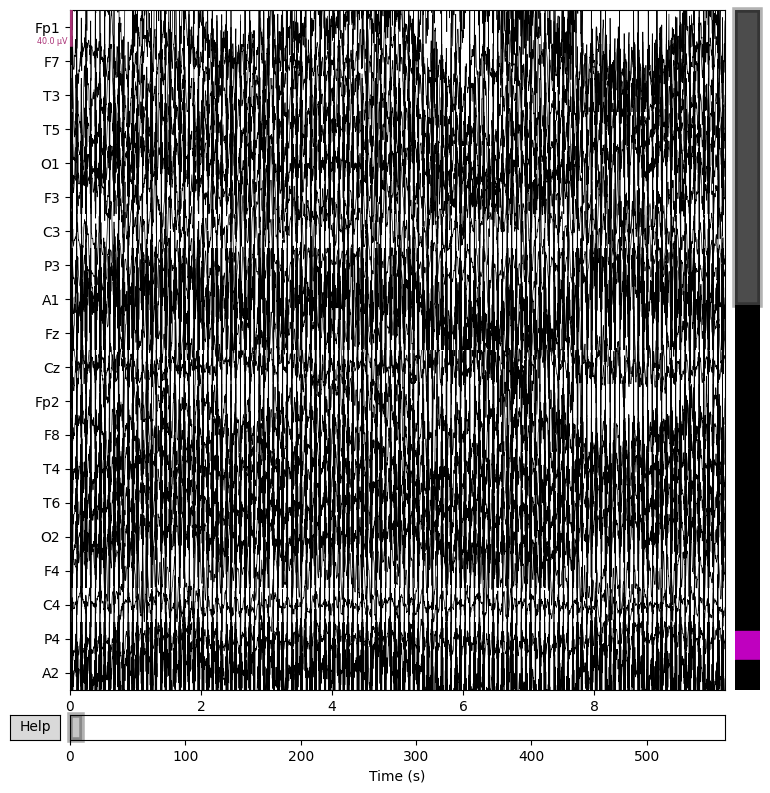

/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_14477/1803301584.py:5: RuntimeWarning: DigMontage is only a subset of info. There are 18 channel positions not present in the DigMontage. The channels missing from the montage are:

['T1', 'T2', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'DC1', 'DC2', 'DC3', 'DC4', 'OSAT', 'PR'].

Consider using inst.rename_channels to match the montage nomenclature, or inst.set_channel_types if these are not EEG channels, or use the on_missing parameter if the channel positions are allowed to be unknown in your analyses.
  raw.set_montage(montage, on_missing='warn')


Montage set: standard_1020
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Set average reference
Effective window size : 8.000 (s)


<Figure size 1200x600 with 0 Axes>

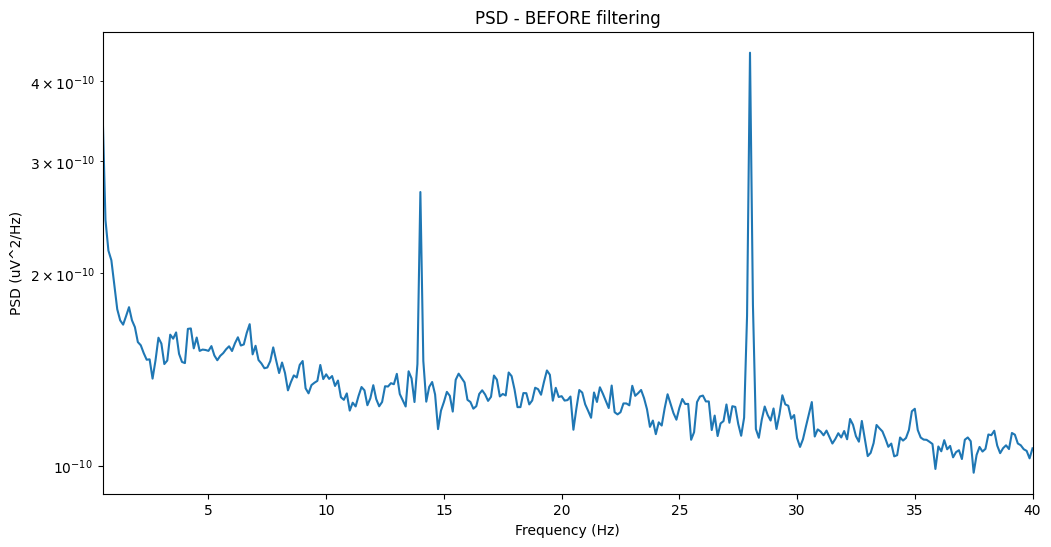

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (6.605 s)

Applied bandpass: 0.5 - 40.0 Hz
Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 1691 sample

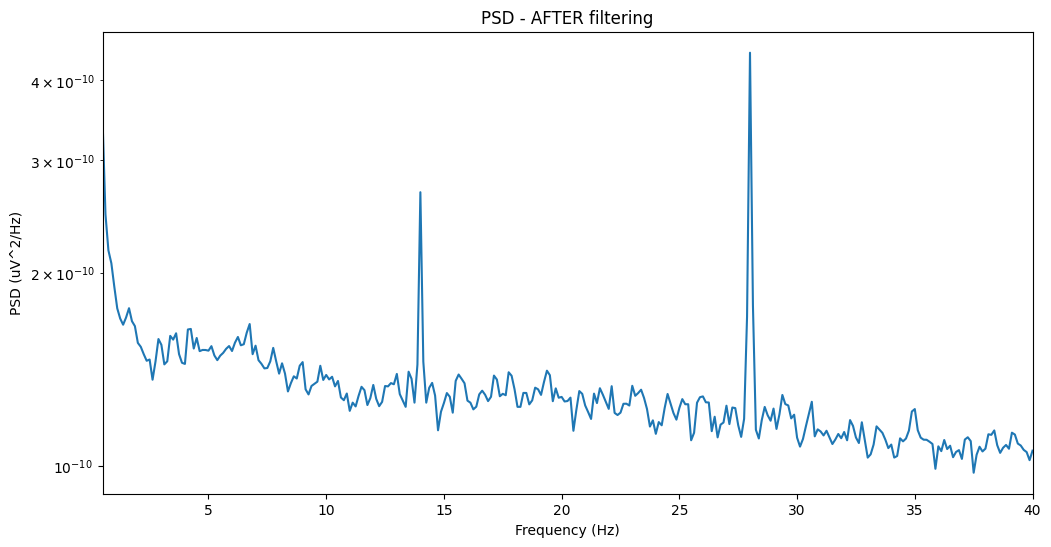

/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_14477/269999343.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  band_powers[band] = np.trapz(psds[:, freq_idx], x=freqs[freq_idx], axis=1)
/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_14477/1506545678.py:11: RuntimeWarning: DigMontage is only a subset of info. There are 18 channel positions not present in the DigMontage. The channels missing from the montage are:

['T1', 'T2', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'DC1', 'DC2', 'DC3', 'DC4', 'OSAT', 'PR'].

Consider using inst.rename_channels to match the montage nomenclature, or inst.set_channel_types if these are not EEG channels, or use the on_missing parameter if the channel positions are allowed to be unknown in your analyses.
  raw_temp.set_montage('standard_1020', on_missing='warn')


ValueError: The following electrodes have overlapping positions, which causes problems during visualization:
T1, T2, X9, X10, X11, X12, X13, X14, X15, X16, X17, X18, DC1, DC2, DC3, DC4, OSAT, PR

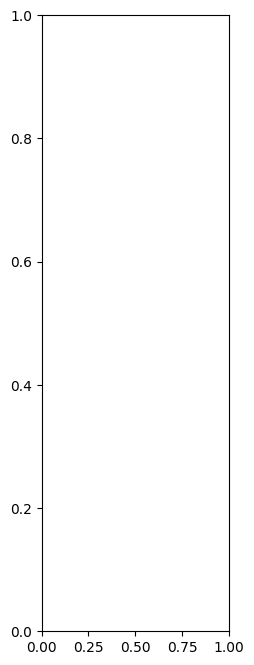

In [17]:
if __name__ == '__main__':
    example_path = '/Users/wanghley/Workspace/Projects/ML-driven EEG biomarkers/data/XU/XUAWAKE7.EDF'  # <- change me
    if Path(example_path).exists():
        pipeline_run(example_path, out_prefix='example')
    else:
        print('No example file found. Replace example_path with your EDF.')